# 데이터분석응용: Star Wars Character Dataset 실습

## 데이터 탐색 및 전처리하기

(1) csv 파일을 불러와 첫 5줄 출력하기

In [ ]:
import pandas as pd

starwars = pd.read_csv('characters.csv')
print("Printing the first 5 lines of dataset:")
starwars.head()

Printing the first 5 lines of dataset:


,id,name,species,gender,height,weight,hair_color,eye_color,skin_color,year_born,homeworld,year_died,description
0,1,Luke Skywalker,Human,Male,1.72,77.0,Blond,Blue,Light,19.0,Tatooine,34.0,The main protagonist of the original trilogy.
1,2,Leia Organa,Human,Female,1.50,49.0,Brown,Brown,Light,19.0,Alderaan,35.0,A leader in the Rebel Alliance and twin sister...
2,3,Darth Vader,Human,Male,2.02,136.0,NaN,Yellow,Pale,41.0,Tatooine,4.0,The Sith Lord formerly known as Anakin Skywalker.
3,4,Yoda,Yoda's species,Male,0.66,17.0,White,Brown,Green,896.0,Unknown,4.0,A wise and powerful Jedi Master.
4,5,Han Solo,Human,Male,1.80,80.0,Brown,Hazel,Light,29.0,Corellia,34.0,A smuggler turned hero in the Rebel Alliance.


(2) 데이터의 전체 구조 확인하기. 몇 개의 numerical column과 categorical column이 있는가?

In [ ]:
starwars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           96 non-null     int64  
 1   name         96 non-null     object 
 2   species      96 non-null     object 
 3   gender       92 non-null     object 
 4   height       95 non-null     float64
 5   weight       92 non-null     float64
 6   hair_color   68 non-null     object 
 7   eye_color    93 non-null     object 
 8   skin_color   96 non-null     object 
 9   year_born    94 non-null     float64
 10  homeworld    95 non-null     object 
 11  year_died    60 non-null     float64
 12  description  96 non-null     object 
dtypes: float64(4), int64(1), object(8)
memory usage: 9.9+ KB


In [ ]:
# numerical columns의 개수를 확인해보자

# numeric_cols = starwars.select_dtypes(include='number').columns
# print("The number of numeric columns is:", len(numeric_cols))
# numeric_cols

numeric_cols = starwars.select_dtypes(include=['int64', 'float64']).columns
print("The number of numeric columns is:", len(numeric_cols))
numeric_cols


The number of numeric columns is: 5


Index(['id', 'height', 'weight', 'year_born', 'year_died'], dtype='object')

In [ ]:
# categorical columns의 개수를 확인해보자
object_cols = starwars.select_dtypes(include='object').columns
print("The number of object columns is:", len(object_cols))
object_cols

The number of object columns is: 8


Index(['name', 'species', 'gender', 'hair_color', 'eye_color', 'skin_color',
       'homeworld', 'description'],
      dtype='object')

(3) 열 지우기. 사용하지 않을 description 열을 지워보자.

In [ ]:
starwars = starwars.drop(columns=['description'])

# starwars.drop(columns=['description'], inplace=True)

starwars.head()

,id,name,species,gender,height,weight,hair_color,eye_color,skin_color,year_born,homeworld,year_died
0,1,Luke Skywalker,Human,Male,1.72,77.0,Blond,Blue,Light,19.0,Tatooine,34.0
1,2,Leia Organa,Human,Female,1.50,49.0,Brown,Brown,Light,19.0,Alderaan,35.0
2,3,Darth Vader,Human,Male,2.02,136.0,NaN,Yellow,Pale,41.0,Tatooine,4.0
3,4,Yoda,Yoda's species,Male,0.66,17.0,White,Brown,Green,896.0,Unknown,4.0
4,5,Han Solo,Human,Male,1.80,80.0,Brown,Hazel,Light,29.0,Corellia,34.0


(4) 결측치 확인하기. 어떤 열에 결측치가 가장 많은가?



In [ ]:
missing_counts = starwars.isnull().sum()
print(missing_counts)

id             0
name           0
species        0
gender         4
height         1
weight         4
hair_color    28
eye_color      3
skin_color     0
year_born      2
homeworld      1
year_died     36
dtype: int64


(5) 기초 통계량 확인하기. 평균 몸무게를 확인하고 평균 몸무게보다 무거운 캐릭터 수를 구해보자.

In [ ]:
starwars.describe()

,id,height,weight,year_born,year_died
count,96.000000,95.000000,92.000000,94.000000,60.000000
mean,48.500000,1.795579,87.945652,68.234043,12.133333
std,27.856777,0.321941,137.175060,143.196941,13.177365
min,1.000000,0.660000,17.000000,0.000000,0.000000
25%,24.750000,1.725000,59.250000,26.750000,0.000000
50%,48.500000,1.800000,75.000000,44.000000,7.000000
75%,72.250000,1.875000,80.000000,52.000000,19.000000
max,96.000000,3.900000,1358.000000,973.000000,35.000000


In [ ]:
heavier_characters = starwars[starwars['weight'] > 75]
print("Chacters heavier than mean weight:", heavier_characters.shape[0])   # or len(heavier_characters)

Chacters heavier than mean weight: 37


(6) 고유값 확인하기. 종(species) 열에 어떤 캐릭터들이 있는지 확인하고 각 species에 속한 캐릭터 수를 구해보자.

In [ ]:
unique_species = starwars['species'].unique()
print("Types of species:", unique_species)

Types of species: ['Human' "Yoda's species" 'Wookiee' 'Gungan' 'Droid' 'Unknown' "Twi'lek"
 'Mon Calamari' 'Mirialan' 'Trandoshan' 'Rodian' 'Hutt' 'Nautolan'
 'Sullustan' 'Kel Dor' 'Dug' 'Togruta' 'Ewok' 'Clawdite' 'Dathomirian'
 'Duros' 'Weequay' 'Besalisk' 'Chiss' 'Ardennian']


In [ ]:
starwars['species'].value_counts()

,count
species,
Human,60
Droid,4
Twi'lek,4
Dathomirian,3
Unknown,2
Togruta,2
Chiss,2
Mon Calamari,2
Gungan,1


(7) 조건별 분포 확인하기. 종(species)이 Human인 캐릭터들 중, 성별(gender)이 남자와 여자인 캐릭터가 각각 몇 명인지 확인해보자.

In [ ]:
human_chars = starwars[starwars['species'] == 'Human']

# gender별 인원 수 세기
gender_counts = human_chars['gender'].value_counts()

print("Gender distribution of Human species:")
print(gender_counts)

Gender distribution of Human species:
gender
Male      46
Female    14
Name: count, dtype: int64


(8) 조건별 집계하기. 각 homeworld별 평균 출생 연도(year_born)를 구해보자.

Hint: groupby() 사용

In [ ]:
starwars.groupby('homeworld')['year_born'].mean()

,year_born
homeworld,
Alderaan,43.000000
Ardennia,40.000000
Arkanis,0.000000
Axxila,59.000000
Bespin,47.000000
Chandrila,26.500000
Concord Dawn,66.000000
Corellia,27.600000
Coruscant,49.000000


(9) 새로운 column 생성하기. Height와 weight를 이용해 BMI라는 새로운 column을 추가하자.

공식: weight/height^2

In [ ]:
starwars['BMI'] = starwars['weight'] / (starwars['height'] ** 2)
starwars[['name', 'height', 'weight', 'BMI']].head()

,name,height,weight,BMI
0,Luke Skywalker,1.72,77.0,26.027582
1,Leia Organa,1.50,49.0,21.777778
2,Darth Vader,2.02,136.0,33.330066
3,Yoda,0.66,17.0,39.026630
4,Han Solo,1.80,80.0,24.691358


(10) 데이터 필터링하기. 비만인 캐릭터들 중 (BMI 25 이상) 아직 살아있는 캐릭터들을 구해보자.

In [ ]:
alive_obese_chars = starwars[(starwars['BMI'] >= 25) & (starwars['year_died'].isna())]

alive_obese_chars[['name', 'BMI', 'year_died']]

,name,BMI,year_died
16,Poe Dameron,25.503616,NaN
21,Lando Calrissian,25.216253,NaN
35,Bossk,31.301939,NaN
46,Nien Nunb,27.343750,NaN
49,Sebulba,31.887755,NaN


## 데이터 시각화하기

(11) species별 캐릭터 수 막대그래프 그려보기

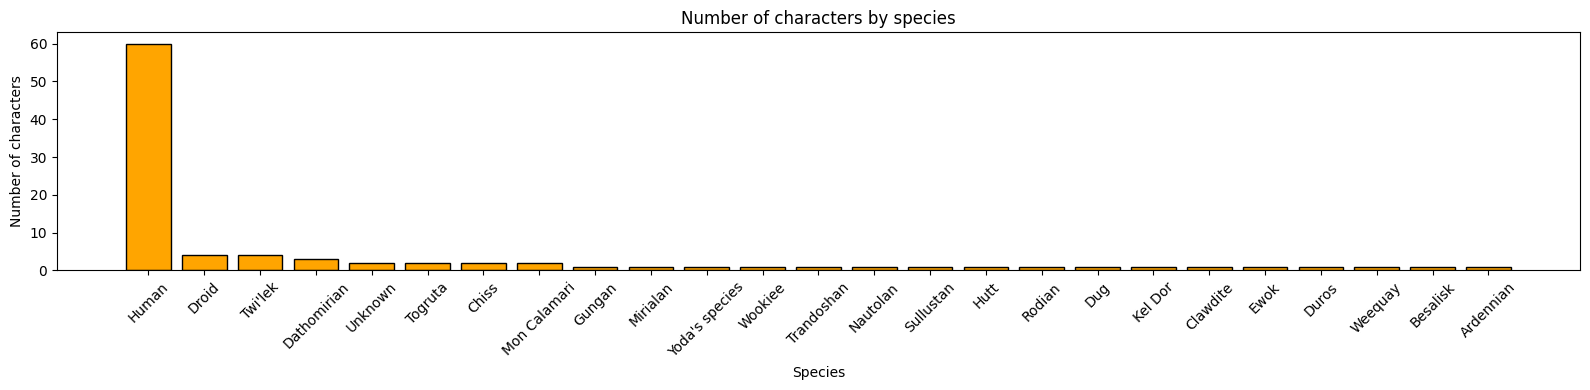

In [ ]:
# https://matplotlib.org/stable/gallery/color/named_colors.html --> Available colors

import matplotlib.pyplot as plt

# species별 캐릭터 수 세기
species_counts = starwars['species'].value_counts()

plt.figure(figsize=(16, 4))
plt.bar(species_counts.index, species_counts.values, color='orange', edgecolor='black')
plt.xticks(rotation=45)
#plt.ylim(0,20)
#plt.yticks([0,5,10,15,20])
plt.xlabel('Species')
plt.ylabel('Number of characters')
plt.title('Number of characters by species')
plt.tight_layout()
plt.show()

(12) species별 평균 키 막대그래프를 그려보자. (NaN이 있다면 drop하기!)

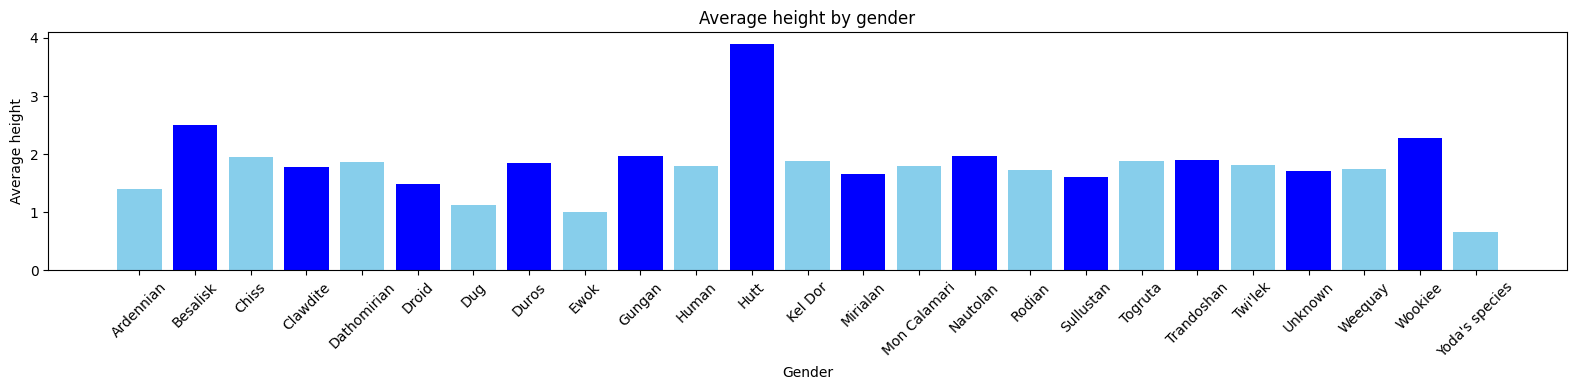

In [ ]:
# gender별 평균 키 계산
gender_height = starwars.groupby('species')['height'].mean().dropna()

plt.figure(figsize=(16, 4))
plt.bar(gender_height.index, gender_height.values, color=['skyblue', 'blue'])
plt.xticks(rotation=45)
plt.xlabel('Gender')
plt.ylabel('Average height')
plt.title('Average height by gender')
plt.tight_layout()
plt.show()

(13) Male / Female 비율 파이그래프를 그려보자

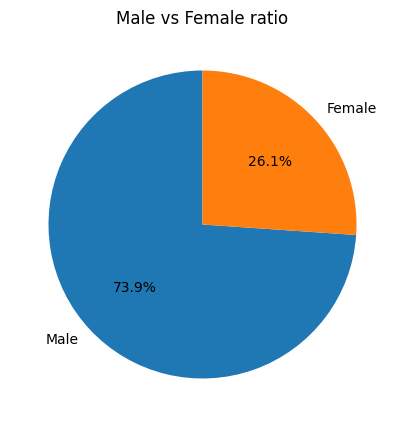

In [ ]:
# male / female 만 사용

mf = starwars[starwars['gender'].isin(['Male', 'Female'])]
# mf = starwars[(starwars['gender']=='Male') | (starwars['gender']=='Female')]
mf_counts = mf['gender'].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(
    mf_counts.values,
    labels=mf_counts.index,
    autopct='%.1f%%',
    startangle=90
)
plt.title('Male vs Female ratio')
plt.show()

(14) hair / eye / skin 색 분포를 나타내는 pie chart 한 화면에 나타내보자

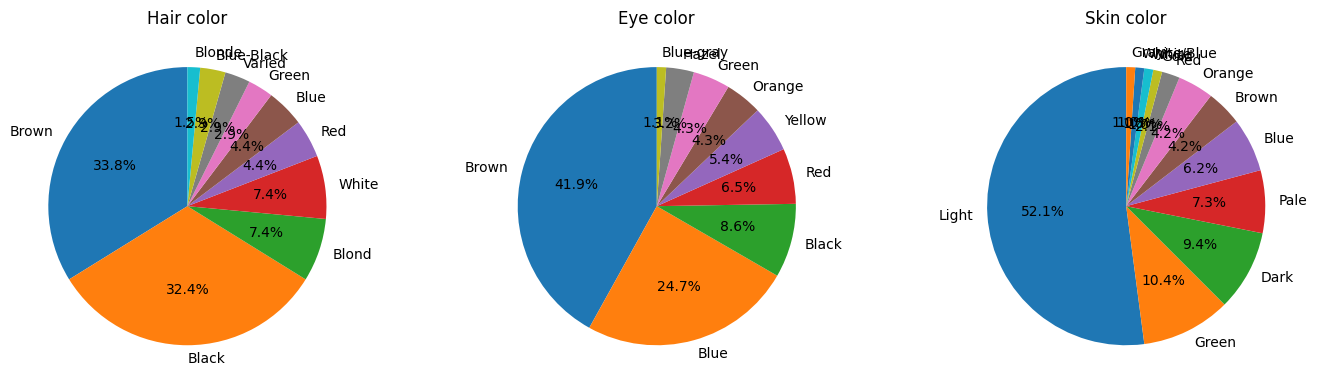

In [ ]:
#fig : “전체 그림” 하나. 여기 안에 여러 개의 그래프(축들)가 들어감.
#axes : 실제로 그래프를 그리는 “좌표 공간(axis)”들

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1) hair_color
hair_counts = starwars['hair_color'].value_counts()
axes[0].pie(
    hair_counts.values,
    labels=hair_counts.index,
    autopct='%.1f%%',
    startangle=90
)
axes[0].set_title('Hair color')

# 2) eye_color
eye_counts = starwars['eye_color'].value_counts()
axes[1].pie(
    eye_counts.values,
    labels=eye_counts.index,
    autopct='%.1f%%',
    startangle=90
)
axes[1].set_title('Eye color')

# 3) skin_color
skin_counts = starwars['skin_color'].value_counts()
axes[2].pie(
    skin_counts.values,
    labels=skin_counts.index,
    autopct='%.1f%%',
    startangle=90
)
axes[2].set_title('Skin color')

plt.tight_layout()
plt.show()

(15) species별 평균 BMI 막대그래프를 그려보자.

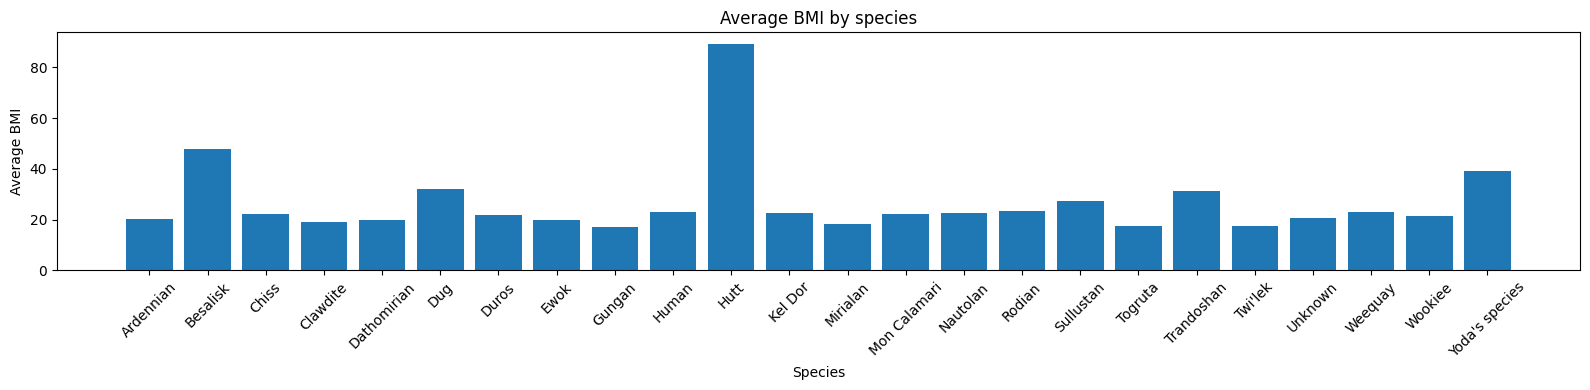

In [ ]:
species_bmi = starwars.groupby('species')['BMI'].mean().dropna()

plt.figure(figsize=(16, 4))
plt.bar(species_bmi.index, species_bmi.values)
plt.xticks(rotation=45)
plt.xlabel('Species')
plt.ylabel('Average BMI')
plt.title('Average BMI by species')
plt.tight_layout()
plt.show()

(16) “All vs Alive: 캐릭터 수와 평균 키 시각화” - 전체 캐릭터와 살아있는 캐릭터 비교

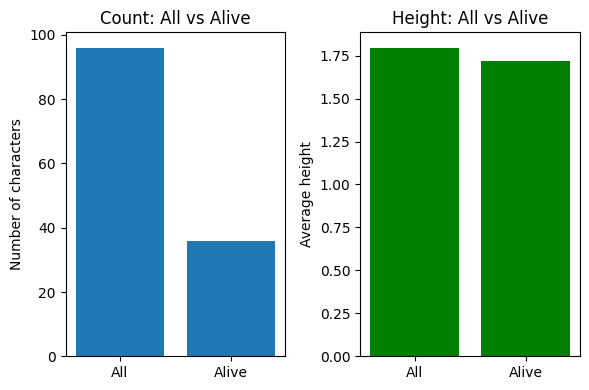

In [ ]:
# 살아있는 캐릭터만 따로 뽑기
alive = starwars[starwars['year_died'].isna()]

# subplot(1, 2) 생성
fig, axes = plt.subplots(1, 2, figsize=(6, 4))

# -------------------------
# (1) 전체 vs 살아있는 캐릭터 수
# -------------------------
labels = ['All', 'Alive']
counts = [len(starwars), len(alive)]

axes[0].bar(labels, counts)
axes[0].set_ylabel('Number of characters')
axes[0].set_title('Count: All vs Alive')

# -------------------------
# (2) 전체 vs 살아있는 캐릭터 평균 키
# -------------------------
height_means = [starwars['height'].mean(), alive['height'].mean()]

axes[1].bar(labels, height_means, color='green')
axes[1].set_ylabel('Average height')
axes[1].set_title('Height: All vs Alive')

plt.tight_layout()
plt.show()

(17) weight에 대한 boxplot을 그리고, outlier를 찾자. 이후 height vs weight 산점도를 그려보자.

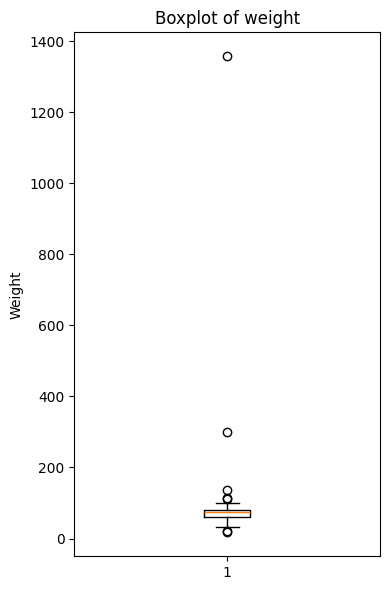

In [ ]:
plt.figure(figsize=(4, 6))
plt.boxplot(starwars['weight'].dropna())
plt.ylabel('Weight')
plt.title('Boxplot of weight')
plt.tight_layout()
plt.show()

원래 개수: 96
이상치 제거 후 개수: 91


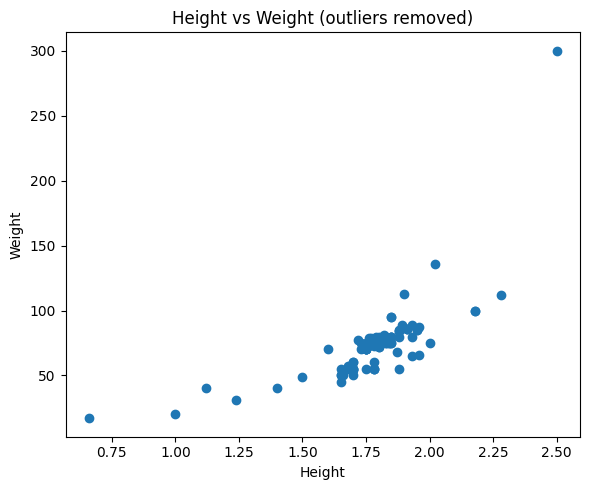

In [ ]:
starwars_clean = starwars[starwars['weight'] < 400]

print("원래 개수:", len(starwars))
print("이상치 제거 후 개수:", len(starwars_clean))

# height vs weight scatterplot (이상치 제거 후)
plt.figure(figsize=(6, 5))
plt.scatter(starwars_clean['height'], starwars_clean['weight'])
plt.xlabel('Height')
plt.ylabel('Weight')
plt.title('Height vs Weight (outliers removed)')
plt.tight_layout()
plt.show()

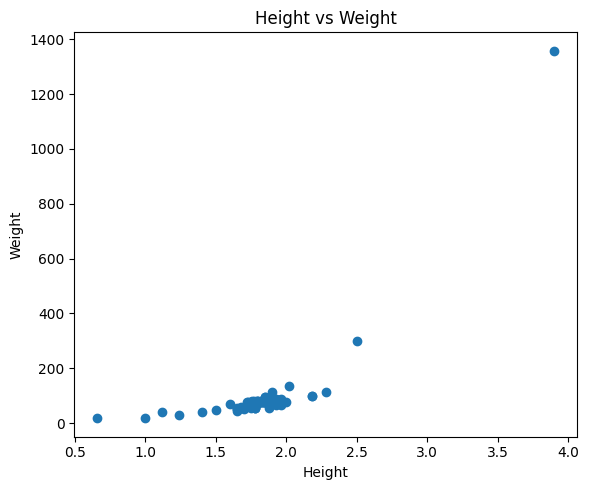

In [ ]:
#제거를 안했으면 나오는 그림

plt.figure(figsize=(6, 5))
plt.scatter(starwars['height'], starwars['weight'])
plt.xlabel('Height')
plt.ylabel('Weight')
plt.title('Height vs Weight')
plt.tight_layout()
plt.show()